# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Quartetos (a interseção com grupos anteriores deve ter tamanho máximo igual a 2)

In [19]:
import os
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi
import shutil
import torch
import re
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import csv
from tqdm import tqdm

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [17]:
load_dotenv()

os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "miljan/stanford-dogs-dataset-traintest",
    path="./data",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest


In [20]:
def class_treatment(path):
    for name in os.listdir(path):
        old_path = os.path.join(path, name)

        if os.path.isdir(old_path):
            new_name = re.sub(r"^n\d{8}-", "", name)
            new_path = os.path.join(path, new_name)

            if new_name != name:
                try:
                    if not os.path.exists(new_path):
                        os.rename(old_path, new_path)
                        print(f"{name} -> {new_name}")
                    else:
                        print(f"ALREADY EXISTS: {new_name}")

                except PermissionError:
                    print(f"PERMISSION DENIED: {name}")

                    try:
                        shutil.move(old_path, new_path)
                        print(f"{name} -> {new_name}")
                    except Exception as e:
                        print(f"FAILED: {name}: {e}")

base_path = "./data/cropped/cropped"

class_treatment(os.path.join(base_path, "train"))
class_treatment(os.path.join(base_path, "test"))

# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),         
    transforms.Normalize(           
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [4]:
base_path = "./data/cropped/cropped"

train_path = f"{base_path}/train"
test_path = f"{base_path}/test"

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=transform
)

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [6]:
images, labels = next(iter(train_loader))

print("Shape das imagens:", images.shape)
print("Labels:", labels[:5])

Shape das imagens: torch.Size([32, 3, 224, 224])
Labels: tensor([100,  41,  18,  51, 104])


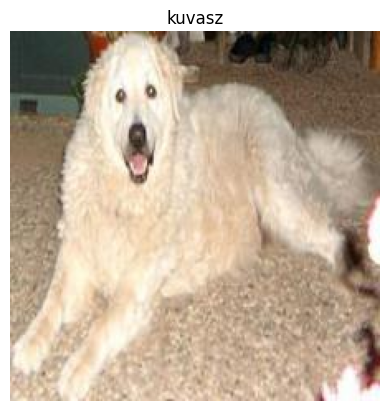

In [8]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0) 

plt.imshow((img * 0.5 + 0.5))
plt.title(train_dataset.classes[labels[0]])
plt.axis('off')
plt.show()

## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    2. E do DataLoader?
    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?

### Resposta 1:

O Image Handler transforma os dados brutos (imagens em pastas) em um dataset estruturado que o modelo pode receber, isso acontece da seguinte maneira:

1. Lê as imagens organizadas em pastas
2. Associa automaticamente cada pasta a uma classe (rotular os dados)
3. Aplica as transformações definidas previamente (resize, tensor, normalização)

### Resposta 2:

O DataLoader gerencia como os dados são entregues ao modelo, da seguinte forma:

1. Divide o dataset em lotes (batches)
2. Controla a ordem dos dados (com ou sem embaralhamento)
3. Carrega os dados de forma eficiente durante o treinamento

### Resposta 3:

Usando todo o conjunto de dados, podemos: estourar a memória, tornar o treinamento mais lento e reduzir a capacidade de generalização do modelo.

Já usando batches menores, temos um treinamento mais estável e melhor eficiência computacional.

### Resposta 4:

O shuffle=True no treinamento é importante pois: evita que o modelo aprenda padrões da ordem dos dados, reduz o overffiting e consequentemente temos uma melhora na capacidade de generalização do modelo.

### Resposta 5:

Já no teste, usamos shuffle=False pois os resultados devem ser reproduzíveis, garantindo consistência na avaliação do modelo.

Quanto ao batch=1, ele nos permite avaliar o desempenho por imagem, facilitando a análise individual.

Ou seja, no teste nosso objetivo é avaliar com precisão, assumimos tais valores para confiabilidade na análise.

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o overfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            # conv 1
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # conv 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # conv 3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            # conv 4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            # conv 5
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # FC6
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            # FC7
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            # FC8 (saída)
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [31]:
num_classes = len(train_dataset.classes)

model = AlexNet(num_classes)

In [32]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total de parâmetros: {total_params}")
print(f"Parâmetros treináveis: {trainable_params}")
print(model)

Total de parâmetros: 58772984
Parâmetros treináveis: 58772984
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReL

## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9
)

Using device: cuda


In [34]:
train_losses = []
train_accuracies = []
num_epochs = 120

model.to(device)

with open("training_metrics.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["epoch", "loss", "accuracy"])

    for epoch in range(num_epochs):
        model.train()
        
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            current_loss = running_loss / (loop.n + 1)
            current_acc = correct / total

            loop.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        writer.writerow([epoch+1, epoch_loss, epoch_acc])
        file.flush()
        os.fsync(file.fileno()) 

        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

Epoch [1/120] - Loss: 4.7877 - Acc: 0.0087


Epoch [2/120] - Loss: 4.7876 - Acc: 0.0077


Epoch [3/120] - Loss: 4.7876 - Acc: 0.0069


Epoch [4/120] - Loss: 4.7875 - Acc: 0.0086


Epoch [5/120] - Loss: 4.7873 - Acc: 0.0083


...

Epoch [116/120] - Loss: 0.0353 - Acc: 0.9902


Epoch [117/120] - Loss: 0.0303 - Acc: 0.9907


Epoch [118/120] - Loss: 0.0351 - Acc: 0.9908


Epoch [119/120] - Loss: 0.0349 - Acc: 0.9918


Epoch [120/120] - Loss: 0.0272 - Acc: 0.9924


## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [35]:
torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes": num_classes
}, "alexnet_model.pth")

In [37]:
torch.save(model, "modelo.pt")

## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho